# 10. K-Means Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [2]:
# --- Load and preprocess housing dataset (Regression) ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_housing = pd.read_csv('housing.csv')
X_reg = df_housing.drop(columns=['median_house_value'])
y_reg = df_housing['median_house_value']

# Handling missing values
X_reg.fillna(X_reg.mean(numeric_only=True), inplace=True)
for col in X_reg.select_dtypes(include=['object']).columns:
    X_reg[col].fillna(X_reg[col].mode()[0], inplace=True)

# Categorical mapping using get_dummies
X_reg = pd.get_dummies(X_reg, drop_first=True)

# Train Test Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scaling
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)
print("Housing dataset ready for regression!")


Housing dataset ready for regression!


## Clustering Housing Dataset using K-Means

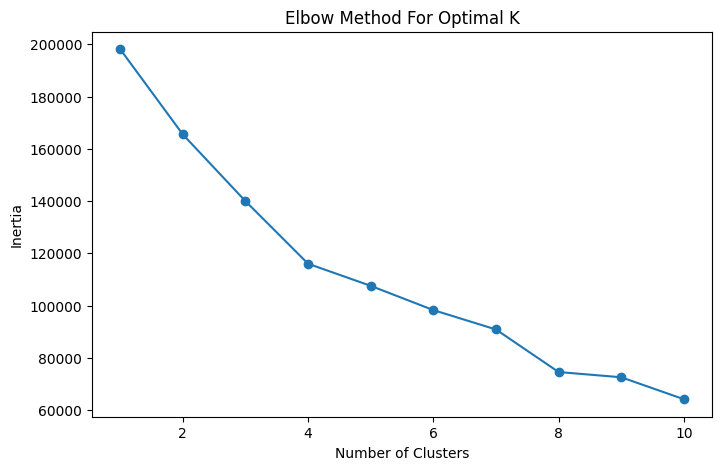

Assigned clusters to data with K=3


In [3]:
from sklearn.cluster import KMeans

# Determine Optimal K using elbow method on scaled features
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_reg_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Based on elbow curve
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
clusters = final_kmeans.fit_predict(X_train_reg_scaled)
print(f"Assigned clusters to data with K={optimal_k}")


## Visualizing Clusters (2D Projection with PCA)

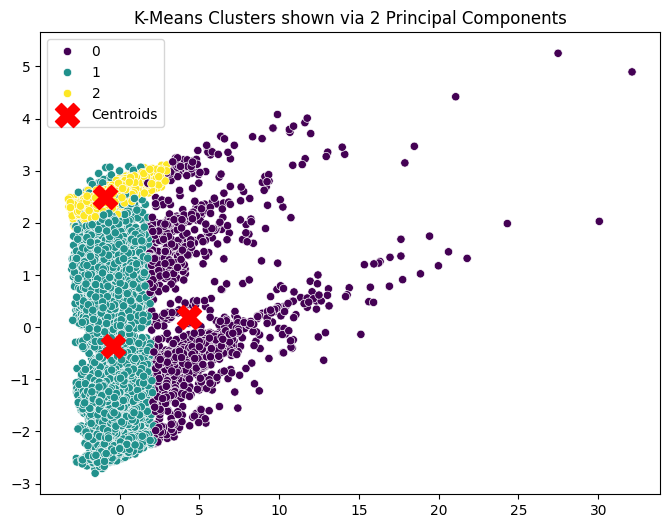

In [7]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Fit KMeans ONCE
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_train_reg_scaled)

# PCA
pca = PCA(n_components=2)
reduced_X = pca.fit_transform(X_train_reg_scaled)

# Transform centroids
reduced_centroids = pca.transform(kmeans.cluster_centers_)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=reduced_X[:, 0],
    y=reduced_X[:, 1],
    hue=clusters,
    palette='viridis'
)

# ONE centroid per cluster
plt.scatter(
    reduced_centroids[:, 0],
    reduced_centroids[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('K-Means Clusters shown via 2 Principal Components')
plt.legend()
plt.show()